# 01. Deep Agents 개요

> **왜 Deep Agents를 배워야 하나요?**
>
> 일반 에이전트(`create_agent`)는 "대화 → 도구 호출 → 응답" 같은 짧은 작업에 적합해요. 하지만 "100페이지 보고서 작성", "코드 리팩토링 프로젝트 관리" 같은 **장시간·다단계 작업**에는 계획 능력, 파일 관리, 컨텍스트 압축 등 추가 능력이 필요해요. Deep Agents는 이런 능력을 미리 갖춰놓은 "강화된 에이전트"예요.

> 🔑 **비유**: `create_agent`가 **택시 기사**(목적지까지 태워다 줌)라면, `create_deep_agent`는 **자율주행차**(경로 계획 + 장애물 회피 + 자동 충전까지 스스로 수행)에 해당해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. LangChain(Framework) → LangGraph(Runtime) → Deep Agents(Harness)의 제품 계층 구조를 설명할 수 있어요
2. Deep Agents가 제공하는 7가지 하네스(Harness) 능력을 나열하고 각 역할을 이해할 수 있어요
3. `create_deep_agent` 함수로 첫 번째 Deep Agent를 만들고 실행할 수 있어요
4. Claude Agent SDK 및 Codex SDK와 Deep Agents의 차이점을 비교 설명할 수 있어요

## 사전 지식

- LangChain V1 기본 (`create_agent`, 메시지 구조)
- LangGraph StateGraph 기초 (노드, 엣지, 체크포인터)
- Part 8에서 다룬 RAG 패턴 및 검색 흐름

## Part 10 학습 지도

Part 10은 Deep Agents 기능을 나열하는 장이 아니라, 장시간 에이전트를 안정적으로 운영하기 위한 **하네스 설계 철학**을 쌓는 장이에요. 각 노트북의 역할은 다음처럼 나눠서 보면 좋아요.

| 노트북 | 역할 | 핵심 질문 |
|---|---|---|
| `01-Deep-Agents-Overview` | Deep Agents가 왜 Harness인지 이해 | 왜 `create_agent`만으로는 긴 작업이 어려울까? |
| `02-Deep-Agent-Capabilities` | 7가지 하네스 능력 실습 | planning, filesystem, subagents, HITL은 어떤 문제를 풀까? |
| `03-Context-Engineering` | 컨텍스트 관리 심화 | 긴 작업에서 무엇을 입력·압축·격리·저장할까? |
| `04-Subagents` | 전문 역할 위임 | 어떤 작업을 메인 에이전트 밖으로 분리할까? |
| `05-Skills-Memory` | 재사용 지식과 장기 기억 | 언제 skills로 늦게 읽고, 언제 memory로 항상 유지할까? |
| `06-Agent-Harness-Patterns` | Part 11로 넘어가는 bridge | Plan / Externalize / Delegate / Isolate / Verify를 어떻게 유스케이스에 적용할까? |

> 🧭 **경계 정리**: Part 10은 철학과 선택 기준을 정리하고, Part 11은 같은 패턴을 SQL, Research, Data Analysis, Three-Agent 같은 도메인 문제에 적용해요.


## 제품 계층 구조 짧은 복습: Framework → Runtime → Harness

LangChain / LangGraph / Deep Agents의 전체 제품 계층은 `01_Introduction/02-Product-Hierarchy.ipynb`에서 이미 자세히 다뤘어요. 이 노트북에서는 Deep Agents가 그 계층 위에서 맡는 역할만 짧게 복습합니다.

```mermaid
flowchart TD
    DA["Deep Agents<br/>Harness"] --> LG["LangGraph<br/>Runtime"]
    LG --> LC["LangChain<br/>Framework"]

    DA_DESC["계획 · 파일시스템 · 권한 · 서브에이전트 · 코드 실행 · HITL"]
    LG_DESC["StateGraph · Checkpointer · Streaming · Interrupt"]
    LC_DESC["모델 · 도구 · 메시지 · create_agent"]

    DA -.-> DA_DESC
    LG -.-> LG_DESC
    LC -.-> LC_DESC

    classDef harness fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef runtime fill:#cce5ff,stroke:#007bff,color:#004085
    classDef framework fill:#d4edda,stroke:#28a745,color:#155724
    class DA,DA_DESC harness
    class LG,LG_DESC runtime
    class LC,LC_DESC framework
```

| 계층 | 소유 단원 | 여기서 필요한 관점 |
|------|----------|------------------|
| Framework | 01~05장 | `create_agent`보다 더 긴 작업에는 추가 하네스가 필요함 |
| Runtime | 02~04장 | Deep Agents도 결국 LangGraph 런타임 위에서 실행됨 |
| Harness | 10장 | 장기 작업에 필요한 도구·권한·서브에이전트·컨텍스트 관리를 묶어 제공 |

> 🔑 **핵심 개념**: Deep Agents는 LangGraph를 대체하지 않아요. LangGraph 위에 장기 실행 에이전트용 하네스를 얹은 것입니다.


## Deep Agents의 하네스(Harness) 능력

**하네스(Harness)**는 공식 문서에서 *"장시간 실행되는 에이전트 구축을 쉽게 만들어 주는 여러 능력의 결합"* 으로 정의돼요. Deep Agents를 "일반 에이전트"와 구분 짓는 것은 바로 이 내장 능력 세트예요.

> 🔑 **용어 정리**
>
> - **Harness**: 에이전트 루프(모델 호출 + 도구 호출)를 감싸고, 장기 실행에 필요한 능력(계획·파일시스템·서브에이전트·권한·HITL 등)을 기본 탑재한 **프레임 구조**예요.
> - **Capability**: Harness가 제공하는 개별 능력. 각각은 내장 도구(`write_todos`, `ls`, `read_file`, `task` 등), 파라미터(`backend`, `interrupt_on`, `skills`, `memory`), 미들웨어 중 하나 이상으로 실현돼요.

```mermaid
flowchart LR
    AGENT["Deep Agent<br>create_deep_agent"]

    AGENT --> P["1. Planning<br>write_todos 도구<br>자동 할일 목록"]
    AGENT --> F["2. Virtual Filesystem<br>ls / read_file / write_file / edit_file / glob / grep"]
    AGENT --> PERM["3. Filesystem Permissions<br>경로·연산별 허용/거부 규칙"]
    AGENT --> S["4. Subagents<br>task 도구<br>서브에이전트 위임"]
    AGENT --> C["5. Context Management<br>오프로딩 · 요약 압축"]
    AGENT --> E["6. Code Execution<br>execute 도구<br>샌드박스 코드 실행"]
    AGENT --> H["7. HITL<br>interrupt_on 설정<br>인간 승인"]

    classDef ability fill:#fff3cd,stroke:#ffc107,color:#856404
    class P,F,PERM,S,C,E,H ability
```

| # | 능력 | 도구/설정 | 설명 |
|---|------|-----------|------|
| 1 | **계획(Planning)** | `write_todos` | 복잡한 작업을 단계별 할일로 분해해요 |
| 2 | **가상 파일시스템(Virtual Filesystem)** | `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep` | `backend`에 따라 상태·디스크·Store·원격으로 투명하게 연결돼요 |
| 3 | **파일시스템 권한(Permissions)** | `FilesystemPermission` | 경로·연산(`read`/`write`/`edit`)별로 허용·거부 규칙을 선언해요 |
| 4 | **서브에이전트(Subagents)** | `task` | 전문 서브에이전트에게 격리된 컨텍스트로 하위 작업을 위임해요 |
| 5 | **컨텍스트 관리** | 오프로딩 + 요약 미들웨어 | 큰 출력은 파일로 이관하고, 히스토리는 필요 시 요약해요 |
| 6 | **코드 실행(Code Execution)** | `execute` (샌드박스 백엔드) | `LocalShellBackend` 또는 원격 샌드박스에서 명령을 실행해요 |
| 7 | **HITL (인간-루프)** | `interrupt_on` | 중요한 도구 호출 전 인간 승인을 요청해요 |

> 🧭 **공식 분류 vs 이 강의 구성**
>
> 공식 [Harness capabilities](https://docs.langchain.com/oss/python/deepagents/harness) 문서는 위 7가지를 열거하고, **Skills**와 **Memory**는 이 하네스 능력을 보조하는 별도 기능으로 따로 소개해요. 이 강의에서도 01/02장에서 7가지 하네스 능력을, 03장에서 컨텍스트 관리 심화를, 04/05장에서 Subagents/Skills/Memory를 순서대로 다뤄요.

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 로드해요
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
# LangSmith 대시보드에서 에이전트 실행 흐름을 확인할 수 있어요
import os
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Deep-Agents"

## 1. create_deep_agent 첫 번째 실습

`create_deep_agent`는 Deep Agents의 진입점이에요. 파라미터 몇 가지로 강력한 에이전트를 만들 수 있어요.

### 핵심 파라미터 (공식 시그니처 발췌)

```python
create_deep_agent(
    model,
    tools,
    *,
    system_prompt,
    middleware,
    subagents,         # SubAgent | CompiledSubAgent | AsyncSubAgent 목록
    skills,            # list[str] — SKILL.md 디렉토리 경로
    memory,            # list[str] — 에이전트가 읽을 메모리 파일 경로
    backend,           # BackendProtocol (StateBackend, FilesystemBackend 등)
    interrupt_on,      # dict[tool_name, InterruptOnConfig]
    response_format,
    ...
) -> CompiledStateGraph
```

| 파라미터 | 타입 | 설명 |
|----------|------|------|
| `model` | str / BaseChatModel | 사용할 모델 (`"openai:gpt-4o-mini"` 등) |
| `tools` | Sequence[Tool] | 에이전트가 사용할 추가 도구 목록 |
| `system_prompt` | str | 에이전트의 역할 및 지침 |
| `subagents` | Sequence[SubAgent] | 전문 서브에이전트 목록 (04장에서 심화) |
| `skills` | list[str] | `SKILL.md` 가 들어있는 디렉토리 경로 목록 |
| `memory` | list[str] | 시작 시 읽을 메모리 파일 경로 목록 |
| `backend` | BackendProtocol | 가상 파일시스템 백엔드 (`StateBackend` 등) |
| `interrupt_on` | dict | 인간 승인이 필요한 도구 설정 |
| `middleware` | Sequence | 재시도·컴팩션 등 추가 미들웨어 |

> 🔑 **핵심 개념**: `create_deep_agent`는 `CompiledStateGraph`를 반환해요. 즉, LangGraph가 컴파일한 그래프 그 자체예요. 우리가 이미 익숙한 `.invoke()`, `.stream()`, `.ainvoke()` 메서드를 그대로 사용할 수 있어요. Deep Agents는 "새로운 것"이 아니라 LangGraph 위에 쌓인 레이어예요.

> 💡 **실무 팁**: `system_prompt`를 구체적으로 작성할수록 에이전트의 행동이 예측 가능해져요. "당신은 X 전문가입니다"보다 "다음 규칙을 따르세요: 1) ... 2) ..." 형태로 작성하는 것이 좋아요.

In [3]:
# ---------------------------------------------------
# Deep Agents 패키지 확인
# ---------------------------------------------------
# deepagents 패키지가 필요해요
# 설치: uv add deepagents
import deepagents

print(f"deepagents 버전: {deepagents.__version__}")

deepagents 버전: 0.5.3


In [ ]:
# ---------------------------------------------------
# 첫 번째 Deep Agent 만들기
# ---------------------------------------------------
# Deep Agents의 핵심 진입점을 가져와요
from deepagents import create_deep_agent

# 인터넷 검색 도구를 정의해요
# 실제 환경에서는 Tavily, DuckDuckGo 등을 사용해요
from langchain.tools import tool


@tool
def internet_search(query: str) -> str:
    """인터넷에서 정보를 검색해요.
    
    Args:
        query: 검색할 질문이나 키워드
    """
    # 실습용 모의(mock) 검색 결과예요.
    # LLM이 일반 NLP/딥러닝 의미로 오해하지 않도록 공식 문서의 핵심 정의를 담아요.
    docs = {
        "langgraph": (
            "LangGraph는 장기 실행(stateful) 에이전트를 만들고 관리·배포하기 위한 "
            "저수준 오케스트레이션 프레임워크이자 런타임입니다. "
            "상태 그래프, durable execution, streaming, HITL, memory를 제공합니다."
        ),
        "deep agents": (
            "Deep Agents는 LangGraph 위에서 복잡한 agentic task를 쉽게 만들도록 제공되는 "
            "하네스입니다. planning, virtual filesystem, subagents, context management, "
            "code execution, HITL 등을 한 번에 구성할 수 있습니다."
        ),
        "harness": (
            "Deep Agents 하네스 능력은 실행 환경, 컨텍스트 관리, 위임, 조정의 범주로 묶이며 "
            "이 강의에서는 Planning, Virtual Filesystem, Filesystem Permissions, Subagents, "
            "Context Management, Code Execution, HITL의 7가지 실습 축으로 다룹니다."
        ),
    }
    query_lower = query.lower()
    matched = [value for key, value in docs.items() if key in query_lower]
    if matched:
        return "\n".join(matched)
    return f"'{query}'에 대한 검색 결과: 관련 정보를 찾았어요. (모의 결과)"


# ---------------------------------------------------
# create_deep_agent로 에이전트 생성
# ---------------------------------------------------
# model: 기본 모델 설정 (gpt-4o-mini 사용)
# tools: 에이전트가 사용할 도구 목록
# system_prompt: 에이전트 역할 및 지침
agent = create_deep_agent(
    model="openai:gpt-4o-mini",  # 기본 모델 (비용 효율)
    tools=[internet_search],      # 인터넷 검색 도구 추가
    system_prompt=(
        "당신은 LangGraph/Deep Agents 강의 보조 에이전트입니다. "
        "LangGraph를 NLP 지식그래프나 일반 언어 분석 기술로 설명하지 마세요. "
        "LangGraph는 stateful agent orchestration/runtime이고, "
        "Deep Agents는 그 위의 agent harness라는 차이를 기준으로 답하세요. "
        "공식 정의가 필요한 질문은 internet_search 도구를 먼저 사용하세요."
    ),
)

# 반환 타입 확인: CompiledStateGraph
print(f"에이전트 타입: {type(agent)}")
# create_deep_agent는 CompiledStateGraph를 반환해요.
# LangGraph의 .invoke(), .stream() 메서드를 그대로 사용할 수 있어요.


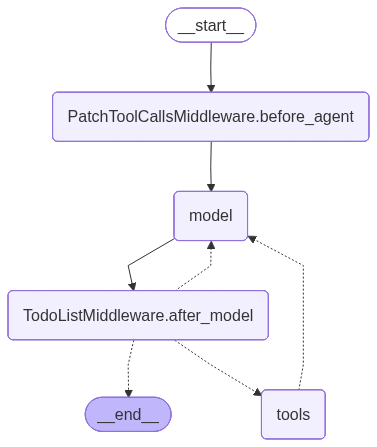

In [5]:
# 그래프 흐름: create_deep_agent가 반환하는 CompiledStateGraph의 내부 구조를 시각화해요
# Deep Agents는 planning, filesystem, context 관리 등 하네스 능력이 내장된 복잡한 그래프예요
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

### 에이전트 실행하기

`create_deep_agent`가 반환한 그래프는 LangGraph의 `CompiledStateGraph`예요. 실행 방법은 이미 알고 있어요!

In [ ]:
# ---------------------------------------------------
# 에이전트 실행: invoke 방식
# ---------------------------------------------------
# LangGraph CompiledStateGraph의 표준 실행 방식이에요
from langchain.messages import HumanMessage

# 입력: 메시지 리스트
inputs = {
    "messages": [HumanMessage(content="LangGraph와 Deep Agents의 차이를 간단히 설명해줘")]
}

# invoke: 동기 실행 (결과가 나올 때까지 기다려요)
result = agent.invoke(inputs)

# 마지막 메시지(AIMessage)를 출력해요
last_message = result["messages"][-1]
# 에이전트 응답:
print(last_message.content)

In [ ]:
# ---------------------------------------------------
# 에이전트 실행: stream 방식 (실시간 출력)
# ---------------------------------------------------
# 실시간으로 에이전트의 실행 과정을 볼 수 있어요
inputs_stream = {
    "messages": [HumanMessage(content="Deep Agents 강의에서 다루는 7가지 하네스 실습 축을 나열해줘")]
}

# 에이전트 실행 중 (스트리밍)...
# --------------------------------------------------

# stream_mode="updates"로 각 노드의 업데이트를 순서대로 받아요
# Deep Agents의 일부 노드는 messages를 Overwrite 객체로 반환하거나 None을 반환해요
for chunk in agent.stream(inputs_stream, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        # node_output이 None이거나 딕셔너리가 아닌 경우 건너뜀
        if not node_output or not isinstance(node_output, dict):
            continue
        print(f"\n[{node_name}] 노드 실행:")
        if "messages" in node_output:
            msgs = node_output["messages"]
            # Overwrite 객체인 경우 .value로 실제 값 추출
            if hasattr(msgs, "value"):
                msgs = msgs.value
            if isinstance(msgs, list):
                for msg in msgs:
                    msg.pretty_print()
            else:
                print(f"  메시지: {msgs}")

## 2. 제품 비교: Deep Agents vs Claude Agent SDK vs Codex

Deep Agents가 유일한 선택지는 아니에요. 비슷한 목적의 도구들과 비교해볼게요. 공식 비교 문서([Comparison with Claude Agent SDK and Codex](https://docs.langchain.com/oss/python/deepagents/comparison))에 기반해 핵심 차이를 정리했어요.

> 🎯 **강의 포인트**: 학생들에게 "어떤 도구를 선택할지는 팀의 기술 스택과 요구사항에 달려 있어요"라고 강조해주세요. LangChain 생태계에 투자한 팀이라면 Deep Agents가 자연스러운 선택이에요. 모델 종류가 제한적이지 않고, 기존 LangChain 코드와 통합이 쉬워요.

| 기능 | Deep Agents | Claude Agent SDK | Codex SDK |
|------|------------|-----------------|----------|
| **지원 모델** | LangChain이 지원하는 모든 공급자 | Anthropic (Bedrock·Vertex·Azure 포함) | OpenAI |
| **메모리/스토어** | `InMemoryStore`, `PostgresStore` 등 LangGraph `BaseStore` 전부 | 별도 구현 필요 | 별도 구현 필요 |
| **파일시스템 백엔드** | 플러그형 (`StateBackend`·`FilesystemBackend`·`StoreBackend`·`LocalShellBackend`·`CompositeBackend`·커스텀) | 기본 샌드박스 | 기본 샌드박스 |
| **샌드박스 아키텍처** | 인-샌드박스 또는 "원격 샌드박스를 도구로" 분리형 모두 가능 | 에이전트가 샌드박스 내부에서 실행 | 에이전트가 샌드박스 내부에서 실행 |
| **멀티테넌시** | 스레드·사용자별 격리 내장, RBAC | 직접 구현 | 직접 구현 |
| **LangGraph 통합** | `CompiledStateGraph` 반환, 동일 API | 없음 | 없음 |
| **스킬 시스템** | Progressive Disclosure (`skills=`) | 없음 | 없음 |
| **HITL** | `interrupt_on` 파라미터 | 직접 구현 | 직접 구현 |
| **배포 형태** | 관리형(LangSmith) / 셀프 호스팅 코드 변경 없이 전환 | 셀프 호스팅 중심 | 셀프 호스팅 중심 |

> 💡 **실무 팁**: Deep Agents의 가장 큰 강점은 **모델·인프라 유연성**이에요. GPT·Claude·Gemini·로컬 모델 등 LangChain이 지원하는 모든 공급자를 코드 변경 없이 교체할 수 있고, 같은 코드가 관리형과 셀프 호스팅 양쪽에서 그대로 돌아가요. 벤더 종속(vendor lock-in)을 피하고 싶은 팀에게 중요한 장점이에요.

## 3. Deep Agents CLI

Deep Agents는 API 외에도 터미널에서 바로 사용할 수 있는 CLI를 제공해요. 코드 작성 없이 에이전트와 대화할 수 있어요.

### 설치 및 실행

```bash
# CLI 포함 설치
uv add deepagents

# 에이전트 시작
deepagents
```

### 주요 CLI 명령어

| 명령어 | 설명 |
|--------|------|
| `/model <provider:model>` | 사용 모델 변경 (예: `/model openai:gpt-4o`) |
| `/remember <내용>` | 장기 메모리에 정보 저장 |
| `/threads` | 이전 대화 스레드 목록 표시 |
| `Ctrl+C` | 대화 종료 |

> 🎯 **강의 포인트**: CLI는 프로토타이핑과 학습에 매우 유용해요. "Deep Agents가 어떻게 동작하는지 직접 느껴보고 싶다면 CLI를 먼저 써보세요"라고 안내해주세요. 실제 프로덕션에서는 `create_deep_agent` API를 사용해요.

> ⚠️ **자주 하는 실수**: CLI에서 `/model` 명령 없이 시작하면 기본 모델(claude-sonnet)을 사용하려고 해요. `OPENAI_API_KEY`만 있다면 `/model openai:gpt-4o-mini`로 먼저 모델을 변경하거나, 환경 변수로 기본 모델을 설정해야 해요.

In [8]:
# ---------------------------------------------------
# CLI 동작 방식 코드로 이해하기
# ---------------------------------------------------
# CLI는 내부적으로 create_deep_agent를 사용해요
# 아래 코드는 CLI와 동일한 구조를 간단히 모사한 것이에요

from deepagents import create_deep_agent
from langchain.messages import HumanMessage

def simple_cli_loop(agent, max_turns: int = 3):
    """CLI와 유사한 간단한 대화 루프예요.
    
    Args:
        agent: create_deep_agent로 만든 에이전트
        max_turns: 최대 대화 횟수 (데모용)
    """
    # 대화 히스토리를 담는 메시지 리스트
    messages = []
    
    # ==================================================
    # Deep Agent CLI 데모 (코드 버전)
    # ==================================================
    
    # 미리 정의한 질문으로 데모 실행
    demo_questions = [
        "안녕하세요! 당신이 할 수 있는 일을 간단히 소개해줘요",
    ]
    
    for question in demo_questions[:max_turns]:
        print(f"\n[사용자] {question}")
        
        # 사용자 메시지를 히스토리에 추가
        messages.append(HumanMessage(content=question))
        
        # 에이전트 실행
        result = agent.invoke({"messages": messages})
        
        # 마지막 AI 응답 가져오기
        ai_response = result["messages"][-1]

        # Deep Agents 응답은 Content Blocks 형식일 수 있어요
        # content가 list([{'type': 'text', 'text': '...'}])이면 텍스트를 추출해요
        content = ai_response.content
        if isinstance(content, list):
            content = " ".join(
                b.get("text", "") if isinstance(b, dict) else str(b)
                for b in content
            )

        print(f"[에이전트] {content}")
        
        # 히스토리 업데이트 (전체 메시지 유지)
        messages = result["messages"]


# CLI 데모 실행
simple_cli_loop(agent)


[사용자] 안녕하세요! 당신이 할 수 있는 일을 간단히 소개해줘요
[에이전트] 안녕하세요! 저는 다양한 작업을 도와줄 수 있는 AI입니다. 주로 다음과 같은 일을 합니다:

- **정보 검색**: 인터넷에서 정보나 자료를 찾아 제공합니다.
- **파일 관리**: 파일 읽기, 쓰기, 편집, 검색 등의 작업을 수행합니다.
- **작업 수행**: 복잡한 작업을 여러 단계로 나누어 실행하거나, 특정 주제에 대한 연구를 진행합니다.
- **데이터 분석 및 요약**: 데이터나 정보를 분석하여 요약하거나 비교합니다.

필요한 작업이 있다면 말씀해 주세요!


## 4. 연결 복원력과 재시도 미들웨어

Deep Agents는 장시간 실행 중 발생하는 일시적 실패(타임아웃·Rate Limit·5xx 에러 등)에 대비한 **복원 미들웨어**를 기본 제공해요. 공식 문서 [Going to production](https://docs.langchain.com/oss/python/deepagents/going-to-production)에서 세 가지를 명시해요.

| 미들웨어 | 역할 | 기본 설정 |
|----------|------|-----------|
| `ModelRetryMiddleware` | 모델 호출 실패 시 자동 재시도 | `max_retries=3`, `backoff_factor=2.0`, `initial_delay=1.0` |
| `ModelFallbackMiddleware` | 기본 모델이 완전히 다운되면 대체 모델로 전환 | 폴백 모델 명시 필요 |
| `ToolRetryMiddleware` | 지정한 도구 호출만 선택적으로 재시도 | 모든 도구가 아니라 선택적으로 적용 권장 |

```mermaid
flowchart LR
    REQ["모델 API 호출"] -->|"일시적 실패"| R1["재시도 1<br>1.0s 대기"]
    R1 -->|"실패"| R2["재시도 2<br>2.0s 대기"]
    R2 -->|"실패"| R3["재시도 3<br>4.0s 대기"]
    R3 -->|"실패"| FALLBACK["Fallback 모델<br>전환 시도"]
    FALLBACK -->|"실패"| ERR["예외 발생"]
    R1 -->|"성공"| OK["작업 계속"]
    R2 -->|"성공"| OK
    R3 -->|"성공"| OK
    FALLBACK -->|"성공"| OK

    classDef fail fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef ok fill:#d4edda,stroke:#28a745,color:#155724

    class ERR fail
    class OK ok
```

> 💡 **실무 팁**: 기본값(`max_retries=3`, exponential backoff)은 대부분의 API 제공자 Rate Limit 회복 시간과 잘 맞아요. 비용이 큰 작업은 **체크포인터(checkpointer)** 와 함께 사용해서, 재시도가 모두 실패해도 중단 지점부터 재개할 수 있도록 하세요.

> ⚠️ **자주 하는 실수**: `ToolRetryMiddleware`를 모든 도구에 적용하지 마세요. 공식 문서도 *"실패한 `read_file` 같은 연산은 재시도해도 의미가 없다"* 고 지적해요. 네트워크 I/O가 포함된 도구에만 선별적으로 적용하는 것이 안전해요.

### 기본 설정 요약

| 항목 | 기본값 | 출처 |
|------|--------|------|
| `max_retries` | 3 | `ModelRetryMiddleware` |
| `backoff_factor` | 2.0 (exponential) | `ModelRetryMiddleware` |
| `initial_delay` | 1.0s | `ModelRetryMiddleware` |
| 재시도 간격 | 1.0s → 2.0s → 4.0s | 초기 지연 × 배수 |

다음 상황에서 자동으로 적용돼요 (공식 Going-to-production 문서):
- 네트워크 타임아웃
- 503 Service Unavailable / 5xx 에러
- Rate Limit (429)
- 기타 일시적 모델 API 장애

> 🔗 **참고**: 미들웨어를 커스터마이즈하려면 `middleware=[ModelRetryMiddleware(max_retries=5, ...)]` 처럼 `create_deep_agent`의 `middleware` 파라미터에 직접 전달하면 돼요.


## 5. 실습: 나만의 Deep Agent 만들기

아래 코드를 수정해서 자신만의 Deep Agent를 만들어보세요.

In [9]:
# ============================================================
# TODO: 나만의 Deep Agent 만들기
# 힌트: system_prompt와 tools를 수정해서 특정 도메인 전문가 에이전트를 만들어보세요
#   - 번역 에이전트: system_prompt에 "당신은 전문 번역가입니다" 추가
#   - 코드 리뷰 에이전트: system_prompt에 Python 코드 리뷰 지침 추가
#   - 요리 레시피 에이전트: 음식 관련 도구 추가
# 예상 결과: 에이전트가 지정한 역할에 맞게 응답해요
# ============================================================

from deepagents import create_deep_agent
from langchain.tools import tool
from langchain.messages import HumanMessage

# --- 도구 정의 (수정해보세요!) ---
@tool
def my_custom_tool(input_text: str) -> str:
    """나만의 커스텀 도구예요. 원하는 기능으로 바꿔보세요.
    
    Args:
        input_text: 도구에 전달할 텍스트
    """
    # TODO: 여기를 원하는 기능으로 바꿔보세요
    return f"처리 결과: {input_text.upper()}"


# --- 에이전트 생성 (수정해보세요!) ---
my_agent = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[my_custom_tool],
    # TODO: system_prompt를 원하는 역할로 수정해보세요
    system_prompt="당신은 유용한 AI 에이전트입니다.",
)

# --- 테스트 실행 ---
# TODO: 아래 질문을 자신의 에이전트에 맞게 변경해보세요
test_question = "안녕하세요! 어떤 도움을 드릴 수 있는지 알려주세요."

result = my_agent.invoke({
    "messages": [HumanMessage(content=test_question)]
})

# Deep Agents의 응답은 Content Blocks 형식이에요
# content가 리스트([{'type': 'text', 'text': '...'}])이면 텍스트를 추출해요
content = result["messages"][-1].content
if isinstance(content, list):
    content = " ".join(
        b.get("text", "") if isinstance(b, dict) else str(b)
        for b in content
    )

# 나의 에이전트 응답:
print(content)

안녕하세요! 필요하신 도움이나 궁금한 점을 말씀해 주시면 최선을 다해 도와드리겠습니다.


## 6. create_deep_agent vs create_agent 비교

`create_agent`의 기본 사용법은 Part 05에서 이미 배웠어요. 여기서는 다시 사용법을 반복하지 않고, **언제 Deep Agents 하네스로 올라가야 하는지**만 비교합니다.

```mermaid
flowchart TD
    Q["어떤 에이전트가 필요한가요?"]

    Q --> A["단순한 질문-답변 또는<br>도구 호출 에이전트"]
    Q --> B["장기 실행 복잡 작업<br>(계획 → 파일 조작 → 코드 실행)"]

    A --> CA["create_agent<br>(LangChain)"]
    B --> DA["create_deep_agent<br>(Deep Agents)"]

    CA --> CA_DESC["빠르고 간단<br>낮은 오버헤드"]
    DA --> DA_DESC["계획·파일시스템 내장<br>자동 컨텍스트 관리<br>재시도 미들웨어"]
```

| 비교 항목 | `create_agent` | `create_deep_agent` |
|-----------|---------------|--------------------|
| 용도 | 간단한 도구 호출 에이전트 | 복잡한 장기 실행 작업 |
| 파일시스템 | 수동 도구 추가 필요 | 내장 (`backend` 설정) |
| 계획 능력 | 직접 구현 필요 | `write_todos` 내장 |
| 컨텍스트 관리 | 수동 구현 필요 | 오프로딩·요약 미들웨어 기본 탑재 |
| 재시도 | 직접 추가 | `ModelRetryMiddleware` 기본 3회 + backoff |
| 오버헤드 | 낮음 | 중간 |


### 코드 비교: create_agent vs create_deep_agent

**방식 1: create_agent (LangChain, Part 5에서 배운 방식)**

```python
from langchain.agents import create_agent

agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[search_tool],
    prompt="도움이 되는 에이전트입니다.",
)
# 반환: CompiledStateGraph (간단한 ReAct 루프)
```

**방식 2: create_deep_agent (Deep Agents)**

```python
from deepagents import create_deep_agent

agent = create_deep_agent(
    model="openai:gpt-4o-mini",
    tools=[search_tool],
    system_prompt="도움이 되는 에이전트입니다.",
    # 추가로 이런 것들이 가능해요:
    # backend=FilesystemBackend(root_dir=".", virtual_mode=True),  # 파일시스템 접근
    # interrupt_on={"write_file": True},                            # 파일 쓰기 전 승인 요청
    # skills=["/skills/"],                                          # 점진적 공개 스킬
    # memory=["/memories/AGENTS.md"],                               # 시작 시 읽을 메모리
)
# 반환: CompiledStateGraph (7가지 하네스 능력 포함)
```

두 방식 모두 `CompiledStateGraph`를 반환하므로 `.invoke()`, `.stream()`, `.ainvoke()` 동일하게 사용해요!


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **계층 복습**: LangChain(Framework) → LangGraph(Runtime) → Deep Agents(Harness) 구조는 01장에서 배웠고, 여기서는 Deep Agents의 하네스 역할만 다시 연결했어요.

- **7가지 하네스 능력**: 계획(Planning), 가상 파일시스템(Virtual Filesystem), 권한(Filesystem Permissions), 서브에이전트(Subagents), 컨텍스트 관리, 코드 실행(Code Execution), HITL(인간-루프)을 미리 갖춰 놓았어요.

- **create_deep_agent**: `model`, `tools`, `system_prompt` 등 몇 가지 파라미터로 장기 실행 에이전트를 만들 수 있어요. 반환 타입은 `CompiledStateGraph`이므로 LangGraph API를 그대로 사용할 수 있어요.

- **create_agent와의 차이**: 단순 도구 호출은 `create_agent`, 계획·파일·코드 실행·서브에이전트가 필요한 장기 작업은 `create_deep_agent`가 더 적합해요.

- **연결 복원력**: `ModelRetryMiddleware` / `ModelFallbackMiddleware` / `ToolRetryMiddleware`가 기본 탑재되어 일시 장애에 강해요.


## 다음 노트북 예고

다음 `02-Deep-Agent-Capabilities.ipynb`에서는 **Deep Agents의 7가지 하네스 능력을 하나씩 실습**해요. 계획(Planning), 가상 파일시스템(Virtual Filesystem), 권한(Filesystem Permissions), 서브에이전트(Subagents), 컨텍스트 관리, 코드 실행(Code Execution), HITL(인간-루프)를 직접 코드로 만들고 실행해봐요.